<a href="https://colab.research.google.com/github/LinaMariaCastro/curso-ia-para-economia/blob/main/clases/5_Aprendizaje_supervisado/5_Taller_Ensamble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** [Lina María Castro](https://www.linkedin.com/in/lina-maria-castro)  
- 📧 **Email:** [lmcastroco@gmail.com](mailto:lmcastroco@gmail.com)  
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

# **Taller Ensamble: Random Forest y Gradient Boosting**

**IMPORTANTE**: Guarda una copia de este notebook en tu Google Drive o computador.

**Taller en grupos de 3**

**Nombres estudiantes:**

- Juan Barrantes
- Daniel Caicedo
- Juan Ordoñez

**Forma de entrega:**

- Nombrar el archivo de la siguiente forma: “Taller_Ensamble_apellidos.ipynb”.
- Suba el Jupyter Notebook a su cuenta en Github y envíe el link en el siguiente Forms: https://forms.cloud.microsoft/r/Hm6L1UMD03.

**IMPORTANTE:** No se recibirán talleres en Google Colab, el notebook debe estar subido en Github.

**Plazo de entrega:**

12 de mayo de 2026, máximo a las 11:59 p.m. Tenga en cuenta que luego de esa hora el formulario en forms se cierra. El Jupupyter Notebook también debe quedar subido en Github antes de esa hora.

**Instrucciones Generales:**

Completa el código en las celdas marcadas con `### TU CÓDIGO AQUÍ ###`. Puedes añadir más celdas si lo requieres.

## Caso de Consultoría: Ames Real Estate Solutions

**Contexto:** Eres un consultor de datos contratado por **Ames Real Estate Solutions**. Tu misión es construir un *pipeline* de Machine Learning robusto para predecir el precio de venta (`SalePrice`) de las viviendas en la ciudad de Ames, Iowa.

**Objetivos:**
1.  Construir un *pipeline* de preprocesamiento profesional usando `ColumnTransformer` y `OneHotEncoder`.
2.  Entrenar y comparar el desempeño en prueba de 3 modelos de regresión: árbol de decisión, random forest y gradient boosting.
3.  Evaluar los modelos usando **R-cuadrado (R²)** y **RMSE** (Raíz del Error Cuadrático Medio).
4.  Optimizar uno de los modelos, el de Random Forest, usando `GridSearchCV` para mejorar su rendimiento en prueba.

### Paso 1: Configuración Inicial

In [1]:
# Importa las librerías necesarias
# Importación de librerías estándar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Módulos de Scikit-Learn para modelado y evaluación
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, mean_squared_error, r2_score
import shap

Mejorar visualización de dataframes y gráficos

In [2]:
# Que muestre todas las columnas
pd.options.display.max_columns = None
# En los dataframes, mostrar los float con dos decimales
pd.options.display.float_format = '{:,.2f}'.format

# Configuraciones para una mejor visualización
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
# Cargar el dataset
url = 'http://jse.amstat.org/v19n3/decock/AmesHousing.txt'
df = pd.read_csv(url, sep='\t')

print(f"Dataset cargado con {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head()

Dataset cargado con 2930 filas y 82 columnas.


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.00,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.00,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.00,Unf,0.00,441.00,"1,080.00",GasA,Fa,Y,SBrkr,1656,0,0,1656,1.00,0.00,1,0,3,1,TA,7,Typ,2,Gd,Attchd,"1,960.00",Fin,2.00,528.00,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.00,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.00,TA,TA,CBlock,TA,TA,No,Rec,468.00,LwQ,144.00,270.00,882.00,GasA,TA,Y,SBrkr,896,0,0,896,0.00,0.00,1,0,2,1,TA,5,Typ,0,NaN,Attchd,"1,961.00",Unf,1.00,730.00,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.00,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.00,TA,TA,CBlock,TA,TA,No,ALQ,923.00,Unf,0.00,406.00,"1,329.00",GasA,TA,Y,SBrkr,1329,0,0,1329,0.00,0.00,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,"1,958.00",Unf,1.00,312.00,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.00,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.00,Gd,TA,CBlock,TA,TA,No,ALQ,"1,065.00",Unf,0.00,"1,045.00","2,110.00",GasA,Ex,Y,SBrkr,2110,0,0,2110,1.00,0.00,2,1,3,1,Ex,8,Typ,2,TA,Attchd,"1,968.00",Fin,2.00,522.00,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.00,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.00,TA,TA,PConc,Gd,TA,No,GLQ,791.00,Unf,0.00,137.00,928.00,GasA,Gd,Y,SBrkr,928,701,0,1629,0.00,0.00,2,1,3,1,TA,6,Typ,1,TA,Attchd,"1,997.00",Fin,2.00,482.00,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


Para este taller, nos enfocaremos en 6 variables predictoras + 1 variable objetivo.

- **Variable Objetivo (Target):**

  - **SalePrice (Precio de Venta):** Es una variable numérica continua que representa el precio final de la transacción de la vivienda en dólares.

- **Variables Predictoras (Features):**

Hemos seleccionado un conjunto mixto de 3 variables numéricas y 3 variables categóricas que intuitivamente tienen un fuerte impacto en el precio:

*Numéricas:*

  - **Overall Qual (Calidad General):** Es una calificación en una escala de 1 a 10 que resume la calidad general del material y los acabados de la casa. Es una medida directa de "lujo" y "calidad de construcción". Una casa con acabados de alta gama (calificación 9 o 10) valdrá mucho más que una con acabados básicos (calificación 4 o 5), incluso si tienen el mismo tamaño.

  - **Gr Liv Area (Área Habitable):** Es el área total en pies cuadrados de los espacios habitables que están sobre el nivel del suelo. Esta variable captura el "tamaño" útil de la vivienda. En igualdad de condiciones, una casa más grande es más valiosa.

  - **Year Built (Año de Construcción):** El año en que la casa fue construida originalmente. Representa la antigüedad de la casa. Las casas más nuevas suelen tener diseños más modernos, mejor eficiencia energética y menos necesidad de reparaciones inmediatas, lo que generalmente aumenta su valor.

*Categóricas:*

  - **Neighborhood (Barrio):** La ubicación física (el barrio) dentro de la ciudad de Ames. Esta variable captura miles de factores ocultos (efectos fijos) como la calidad de las escuelas, la seguridad, el prestigio social, el acceso a parques y el tiempo de desplazamiento.

  - **House Style (Estilo de Casa):** El estilo de la vivienda (ej. 1Story - 1 piso, 2Story - 2 pisos, SLvl - Niveles divididos). Diferentes estilos de construcción tienen diferentes costos y atraen a diferentes segmentos de compradores.

  - **Exter Qual (Calidad Exterior):** Calificación de la calidad de los materiales en el exterior de la casa (ej. Ex - Excelente, Gd - Bueno, TA - Típico/Promedio, Fa - Justo). Mide la calidad del "cascarón" de la casa y el "atractivo visual".

In [4]:
features = [
    'Overall Qual',  # Numérica (ordinal)
    'Gr Liv Area',   # Numérica
    'Year Built',    # Numérica
    'Neighborhood',  # Categórica
    'House Style',   # Categórica
    'Exter Qual'     # Categórica (ordinal)
]
target = 'SalePrice'
df_model = df[features + [target]].copy()
df_model.head()

,Overall Qual,Gr Liv Area,Year Built,Neighborhood,House Style,Exter Qual,SalePrice
0,6,1656,1960,NAmes,1Story,TA,215000
1,5,896,1961,NAmes,1Story,TA,105000
2,6,1329,1958,NAmes,1Story,TA,172000
3,7,2110,1968,NAmes,1Story,Gd,244000
4,5,1629,1997,Gilbert,2Story,TA,189900


### Paso 2: Preprocesamiento y Creación del Pipeline

Pasos:

1.  Separar `X` e `y`.
2.  Separar en `train` y `test` **antes** de cualquier transformación para evitar fuga de datos.
3.  Definir un `ColumnTransformer` que sepa qué hacer con las columnas numéricas y categóricas.
4.  Ajustar (`fit_transform`) el transformador SÓLO en los datos de `train`.

In [5]:
X = df_model[features]
y = df_model[target]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Tamaño de X_train: {X_train.shape}")
print(f"Tamaño de X_test: {X_test.shape}")

Tamaño de X_train: (2344, 6)
Tamaño de X_test: (586, 6)


In [7]:
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

print(f"Columnas Numéricas: {list(numerical_features)}")
print(f"Columnas Categóricas: {list(categorical_features)}")

Columnas Numéricas: ['Overall Qual', 'Gr Liv Area', 'Year Built']
Columnas Categóricas: ['Neighborhood', 'House Style', 'Exter Qual']


In [8]:
# Crear el transformador para las categóricas
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Crear el preprocesador (ColumnTransformer)
# Recuerda que, en este caso, no vamos a estandarizar las variables numéricas
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('num', 'passthrough', numerical_features)
    ],
    remainder='drop'
)

In [9]:
# Tarea 2.5: Aplicar el preprocesador
# Ajustamos (fit) y transformamos el set de entrenamiento
X_train_processed = preprocessor.fit_transform(X_train)

# SÓLO transformamos el set de prueba (ya "aprendió" del train)
X_test_processed = preprocessor.transform(X_test)

print(f"\nForma de X_train procesado: {X_train_processed.shape}")
print(f"Forma de X_test procesado: {X_test_processed.shape}")


Forma de X_train procesado: (2344, 43)
Forma de X_test procesado: (586, 43)


### Paso 3: Modelos Base (Baseline)

Entrenemos 3 modelos: árbol de decisión, random forest y gradient boosting.

In [10]:
# Tarea 3.1: Árbol de Decisión (Baseline)

# Inicializa el modelo, usa DecisionTreeRegressor
# Coloca como semilla random_state=42
dtr_model = DecisionTreeRegressor(random_state=42)

# Entrena el modelo
dtr_model.fit(X_train_processed, y_train)

# Realiza predicciones en el conjunto de prueba
y_pred_dtr = dtr_model.predict(X_test_processed)

In [11]:
# Tarea 3.2: Random Forest (Baseline)

# Inicializa el modelo, usa RandomForestRegressor
# Coloca como semilla random_state=42 y pide que use todos los núcleos del computador n_jobs=-1
# Usa los siguientes hiperparámetros: n_estimators= 500 - max_depth=10 - min_samples_leaf=2
rf_model = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=500, max_depth=10, min_samples_leaf=2)

# Entrena el modelo
rf_model.fit(X_train_processed, y_train)

# Realiza predicciones en el conjunto de prueba
y_pred_rf = rf_model.predict(X_test_processed)

In [12]:
# Tarea 3.3: Gradient Boosting (Baseline)

# Inicializa el modelo, usa GradientBoostingRegressor
# Coloca como semilla random_state=42
gbr_model = GradientBoostingRegressor(random_state=42)

# Entrena el modelo
gbr_model.fit(X_train_processed, y_train)

# Realiza predicciones en el conjunto de prueba
y_pred_gbr = gbr_model.predict(X_test_processed)

### Paso 4: Comparación de Métricas (Baseline)

In [15]:
# Crea una dataframe que muestre para cada modelo el RMSE y el R2.
# Ordena el dataframe de menor a mayor RMSE

# Calcular métricas para el Decision Tree Regressor
rmse_dtr = np.sqrt(mean_squared_error(y_test, y_pred_dtr))
r2_dtr = r2_score(y_test, y_pred_dtr)

# Calcular métricas para el Random Forest Regressor
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

# Calcular métricas para el Gradient Boosting Regressor
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

# Crear un DataFrame para comparar los modelos
metrics_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'RMSE': [rmse_dtr, rmse_rf, rmse_gbr],
    'R2': [r2_dtr, r2_rf, r2_gbr]
})

# Ordenar el DataFrame por RMSE de menor a mayor
metrics_df = metrics_df.sort_values(by='RMSE', ascending=True)

print("Comparación de Métricas de Modelos Baseline:")
print(metrics_df)

Comparación de Métricas de Modelos Baseline:
               Model      RMSE   R2
1      Random Forest 30,064.75 0.89
2  Gradient Boosting 32,383.26 0.87
0      Decision Tree 35,544.40 0.84


¿Cuál modelo tuvo un mejor desempeño en el dataset de prueba (menor RMSE, mayor R²)?

**Respuesta**

El modelo Random Forest es el más preciso y robusto para este dataset, ya que combina el menor error de predicción con la mayor capacidad explicativa.
Por lo tanto, Random Forest sería el modelo recomendado para realizar predicciones futuras con este conjunto de datos.

### Paso 5: Optimización con GridSearchCV para Random Forest

La búsqueda de los hiperparámetros óptimos con `GridSearchCV` se puede realizar para los 3 modelos, sin embargo, como esto toma tiempo, en este taller lo realizaremos solo para el modelo Random Forest.

In [14]:
# Analiza este código, entiende sus pasos y ejecútalo:

print("Iniciando GridSearchCV para Random Forest... (Esto puede tardar 2-3 minutos)")

# Tarea 5.1: Definir la parrilla de parámetros para Random Forest
# Hiperparámetros clave de RF:
# - n_estimators: Número de árboles
# - max_depth: Profundidad máxima (None = sin límite)
# - min_samples_leaf: Mínimo de muestras en una "hoja" final

param_grid_rf = {
    'n_estimators': [100, 200],       # Prueba con 100 y 200 árboles
    'max_depth': [None, 10],          # Prueba árboles sin límite y árboles podados a 10
    'min_samples_leaf': [1, 2],       # Prueba requiriendo 1 o 2 muestras por hoja
}
# Total combinaciones: 2 * 2 * 2 = 8 combinaciones. (8 * 5 folds = 40 modelos)

# Tarea 5.2: Inicializar el GridSearchCV
# Le pasamos un modelo base de RF.
# n_jobs=-1 en el estimador base acelera el entrenamiento de CADA árbol.
rf_base_model = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search_rf = GridSearchCV(
    estimator=rf_base_model,
    param_grid=param_grid_rf,
    cv=5,
    scoring='neg_mean_squared_error', # Usamos el error cuadrático medio negativo (scikit-learn siempre maximiza)
    n_jobs=-1,  # n_jobs=-1 aquí acelera el "GridSearch" (corre los 5 folds en paralelo)
    verbose=1
)

# Tarea 5.3: Ejecutar la búsqueda
grid_search_rf.fit(X_train_processed, y_train)

print("¡Búsqueda completada!")
print(f"Mejores parámetros encontrados: {grid_search_rf.best_params_}")

Iniciando GridSearchCV para Random Forest... (Esto puede tardar 2-3 minutos)
Fitting 5 folds for each of 8 candidates, totalling 40 fits
¡Búsqueda completada!
Mejores parámetros encontrados: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 100}


Investiga por qué en GridSearchCV se usa como métrica el error cuadrático medio **negativo**. A continuación escribe la explicación.

**Respuesta**

En GridSearchCV de la librería [scikit-learn](https://scikit-learn.org?utm_source=chatgpt.com) se utiliza la métrica neg_mean_squared_error (error cuadrático medio negativo) porque el algoritmo está diseñado para **maximizar** la métrica de evaluación, mientras que el Mean Squared Error (MSE) es una métrica que, por naturaleza, debe minimizarse.

### ¿Por qué se usa el valor negativo?

El MSE se define como:

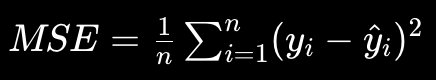


Un valor más pequeño de MSE indica mejores predicciones. Sin embargo, GridSearchCV compara los modelos seleccionando aquel con el **score más alto**. Para mantener una convención uniforme en la que “más alto es mejor”, scikit-learn multiplica el MSE por -1:

neg_MSE = -MSE

De esta forma:

* Si un modelo tiene MSE = 100, entonces neg_mean_squared_error = -100.
* Si otro modelo tiene MSE = 50, entonces neg_mean_squared_error = -50.

Como -50 es mayor que -100, GridSearchCV seleccionará correctamente el modelo con menor error.

### Interpretación práctica

Cuando revisas best_score_ o los resultados de validación cruzada, el valor aparecerá como negativo. Esto no significa que el error sea realmente negativo; simplemente es una transformación para que el proceso de optimización funcione bajo la regla de maximización.

Para obtener el MSE real, se cambia el signo:

```python
mse = -grid.best_score_
```

Y si deseas el RMSE:

```python
rmse = (-grid.best_score_) ** 0.5
```

### Conclusión

GridSearchCV utiliza neg_mean_squared_error porque todas las métricas internas se comparan maximizando su valor. Al convertir el MSE en negativo, el algoritmo puede seguir usando esa misma lógica y, al mismo tiempo, elegir el modelo con el menor error cuadrático medio.


### Paso 6: Evaluación Final del Modelo Random Forest Optimizado

Ahora, usemos nuestro modelo ganador y optimizado (best_estimator_) para hacer predicciones en el set de prueba y ver si el RMSE mejoró respecto a nuestro Random Forest base.

In [16]:
# Tarea 6.1: Obtener el mejor modelo de RF y predecir
best_rf_model = grid_search_rf.best_estimator_
y_pred_rf_optimizado = best_rf_model.predict(X_test_processed)

# Tarea 6.2: Calcular métricas sobre el set de prueba (RMSE y R2)
rmse_rf_optimizado = np.sqrt(mean_squared_error(y_test, y_pred_rf_optimizado))
r2_rf_optimizado = r2_score(y_test, y_pred_rf_optimizado)

print(f"RMSE Random Forest Optimizado: {rmse_rf_optimizado:,.2f}")
print(f"R2 Random Forest Optimizado: {r2_rf_optimizado:,.2f}")

# Compara los resultados en el set de prueba del modelo base de Random Forest y del Random Forest con optimización de hiperparámetros
# ¿Se redujo el RMSE? ¿En cuánto se redujo?
print("\n--- Comparación con el Modelo Base de Random Forest ---")
print(f"RMSE Random Forest Base: {rmse_rf:,.2f}")
print(f"R2 Random Forest Base: {r2_rf:,.2f}")

if rmse_rf_optimizado < rmse_rf:
    reduccion_rmse = rmse_rf - rmse_rf_optimizado
    print(f"¡El RMSE se redujo en {reduccion_rmse:,.2f} al optimizar el modelo!")
else:
    print("El RMSE no se redujo (o aumentó) con la optimización.")

RMSE Random Forest Optimizado: 29,187.99
R2 Random Forest Optimizado: 0.89

--- Comparación con el Modelo Base de Random Forest ---
RMSE Random Forest Base: 30,064.75
R2 Random Forest Base: 0.89
¡El RMSE se redujo en 876.75 al optimizar el modelo!


### Paso 7: Conclusión de Consultoría

Basado en los resultados finales, responde a tu cliente.

**Pregunta 1:** ¿Cuánto logramos reducir el error (RMSE) al optimizar el modelo Random Forest con GridSearchCV? (Compara el RMSE base de RF vs. el RMSE final).


**Respuesta**

El modelo Random Forest base tenía un RMSE de 30,064.75, mientras que el modelo optimizado con GridSearchCV obtuvo un RMSE de 29,187.99.
La reducción del error fue:

30,064.75 − 29,187.99 = 876.76

Es decir, el proceso de optimización redujo el error en aproximadamente 876.75 unidades (la pequeña diferencia se debe al redondeo).


Esto significa que, en promedio, las predicciones del modelo optimizado se acercaron cerca de 877 unidades más al valor real respecto al modelo base. Aunque el R² permaneció en 0.89, la disminución del RMSE demuestra que el ajuste de hiperparámetros permitió obtener predicciones más precisas.


**Pregunta 2:** ¿Por qué fue crucial usar `ColumnTransformer` y hacer el `train_test_split` antes de transformar los datos? ¿Qué problema evitamos?

**Respuesta**

Fue fundamental realizar primero la separación entre entrenamiento y prueba y luego aplicar las transformaciones con ColumnTransformer porque así las transformaciones se ajustan únicamente con la información del conjunto de entrenamiento.

ColumnTransformer permite aplicar distintos preprocesamientos a diferentes tipos de variables, por ejemplo:
Escalar variables numéricas.
Codificar variables categóricas con One-Hot Encoding.
Imputar valores faltantes.


Este procedimiento evitó el problema conocido como data leakage (fuga de información).

El data leakage ocurre cuando información del conjunto de prueba se utiliza indirectamente durante el entrenamiento, por ejemplo al calcular:
medias y desviaciones estándar para escalar,
categorías para codificar,
valores para imputar datos faltantes.

Si estas estadísticas se calculan usando todo el dataset antes de separar los datos, el modelo “conoce” información del conjunto de prueba, lo que genera métricas artificialmente mejores y una evaluación poco confiable.


El flujo correcto es:
- Dividir los datos con train_test_split.
- Ajustar (fit) el ColumnTransformer solo con X_train.
- Transformar X_train y X_test.
- Entrenar el modelo con los datos transformados.

Beneficio principal

De esta forma, el conjunto de prueba permanece completamente “desconocido” para el modelo hasta la evaluación final, lo que garantiza una medición honesta del desempeño y una mejor capacidad de generalización.